# Linear Spectral Decomposition for REE Detection: PCA

## Objective

Apply **PCA** to hyperspectral EnMAP data and evaluate spatial and spectral results to identify rare earth element (REE) minerals.

## Workflow

1. Load and preprocess EnMAP data
2. Apply a linear decompositions on *cleaned reflectance data:
   - **PCA**: Variance-maximizing orthogonal decomposition
3. Evaluate spectral variability and generate scree plots
4. Create spatial component maps
5. Create loading spectra of the corresponding spatial maps
*Data is was preprocessed to remove bands known to overlap in the SWIR and VNIR overlap region and other issues detailed in my thesis
## Mathematical Background

### Problem Formulation

Given hyperspectral datacube **X** ∈ ℝ^(r×c×b) where:
- r, c = spatial dimensions (rows, columns)
- b = spectral bands

We model each pixel spectrum as:

```
x(λ) = m + Σᵢ aᵢeᵢ(λ) + ε(λ)
```

where:
- **m** ∈ ℝ^b = mean spectrum
- **eᵢ**(λ) = basis vectors/loadings in spectral space
- aᵢ = abundance coefficients/scores
- ε(λ) = noise

### Goal

Create interpretable spatial maps from the PCA scores and interpretable wavelength variation from the PCA loadings

In [1]:
# ══════════════════════════════════════════════════════════════════
#  IMPORTS
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import os
import glob
import urllib.request
from scipy.ndimage import uniform_filter
from scipy.stats import pearsonr
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from sklearn.decomposition import PCA, FastICA
import spectral
import sys
from pathlib import Path 
import yaml

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



Matplotlib is building the font cache; this may take a moment.


## Configuration

In [2]:
# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════════════

# ROI coordinates (adjust to your scene)
ROI_ROW1, ROI_COL1 = 931, 451#316, 330#545, 547#
ROI_ROW2, ROI_COL2 = 1035, 579#395, 445#714, 876#

# Decomposition settings
N_COMP = 20  # Number of components to extract

# Project structure
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

# USGS spectral library
USGS_FOLDER = DATA_DIR / "usgs_folder"

print(f"Project root: {PROJECT_ROOT}")
print(f"USGS folder: {USGS_FOLDER}")

print('Configuration loaded')
print(f'ROI: ({ROI_ROW1},{ROI_COL1}) to ({ROI_ROW2},{ROI_COL2})')
print(f'Components: {N_COMP}')

Project root: C:\Users\esppr\bachelor-thesis
USGS folder: C:\Users\esppr\bachelor-thesis\data\usgs_folder
Configuration loaded
ROI: (931,451) to (1035,579)
Components: 20


In [3]:
CONFIG_PATH = PROJECT_ROOT / "config" / "data_config.yaml"

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Configuration file not found: {CONFIG_PATH}\n"
        "Copy config/data_config.example.yaml to "
        "config/data_config.yaml and set your local data paths."
    )

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

HDR_PATH = Path(config["enmap_hdr"])

if not HDR_PATH.exists():
    raise FileNotFoundError(
        f"EnMAP HDR file not found:\n{HDR_PATH}\n"
        "Check the path in config/data_config.yaml"
    )

print(f"Using EnMAP scene: {HDR_PATH}")

Using EnMAP scene: C:\SpecStuff\2idk\ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z\ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z-SPECTRAL_IMAGE.HDR


## Load EnMAP Band Centers

In [4]:
# ══════════════════════════════════════════════════════════════════
#  LOAD ENMAP BAND CENTERS
# ══════════════════════════════════════════════════════════════════
from src.enmap_data import load_enmap_bands
# Download and parse EnMAP band centers
url = "https://www.enmap.org/data/doc/EnMAP_Spectral_Bands_update.xlsx"
excel_path = DATA_DIR / "EnMAP_Spectral_Bands.xlsx"

if not Path(excel_path).exists():
    print(f'Downloading EnMAP band data from {url}...')
    urllib.request.urlretrieve(url, excel_path)


enmap_centers, enmap_fwhm = load_enmap_bands(excel_path)
wl_all = np.array(enmap_centers)

print(f'Loaded {len(wl_all)} EnMAP band centers')
print(f'Range: {wl_all[0]:.1f}–{wl_all[-1]:.1f} nm')
print(f'VNIR: bands 1-88 (~420-1000 nm)')
print(f'SWIR: bands 89-224 (~1000-2450 nm)')

Loaded 224 EnMAP band centers
Range: 418.4–2445.3 nm
VNIR: bands 1-88 (~420-1000 nm)
SWIR: bands 89-224 (~1000-2450 nm)


## Load Hyperspectral Cube

In [5]:
from src.enmap_data import load_hyperspectral_cube

cube_data, wl_all = load_hyperspectral_cube(HDR_PATH, wl_all, ROI_ROW1, ROI_ROW2, ROI_COL1, ROI_COL2)
n_rows, n_cols, n_bands = cube_data.shape

Loading: ENMAP01-____L2A-DT0000045172_20230929T185849Z_001_V010506_20260323T111352Z-SPECTRAL_IMAGE.HDR

 Raw cube shape: (1159, 1233, 224)  (rows × cols × bands)
 Scaled DN → reflectance (÷10000)
 Cropped to ROI: (104, 128, 224)
 Working with 224 bands (418.4–2445.3 nm)


In [6]:
# ══════════════════════════════════════════════════════════════════
#  BAND MASKING (Remove overlap & atmospheric bands)
# ══════════════════════════════════════════════════════════════════
from src.enmap_data import create_band_mask

band_mask, _, _ = create_band_mask(wl_all, enmap_fwhm)

cube_data = cube_data[:, :, band_mask]
wl_all    = wl_all[band_mask]
n_rows, n_cols, n_bands = cube_data.shape
print(f'Bands: {len(wl_all)} ({wl_all[0]:.1f}–{wl_all[-1]:.1f} nm)')

Bands: 196 (424.0–2422.8 nm)


## Visualization of Hyperspectral Scene and Cube

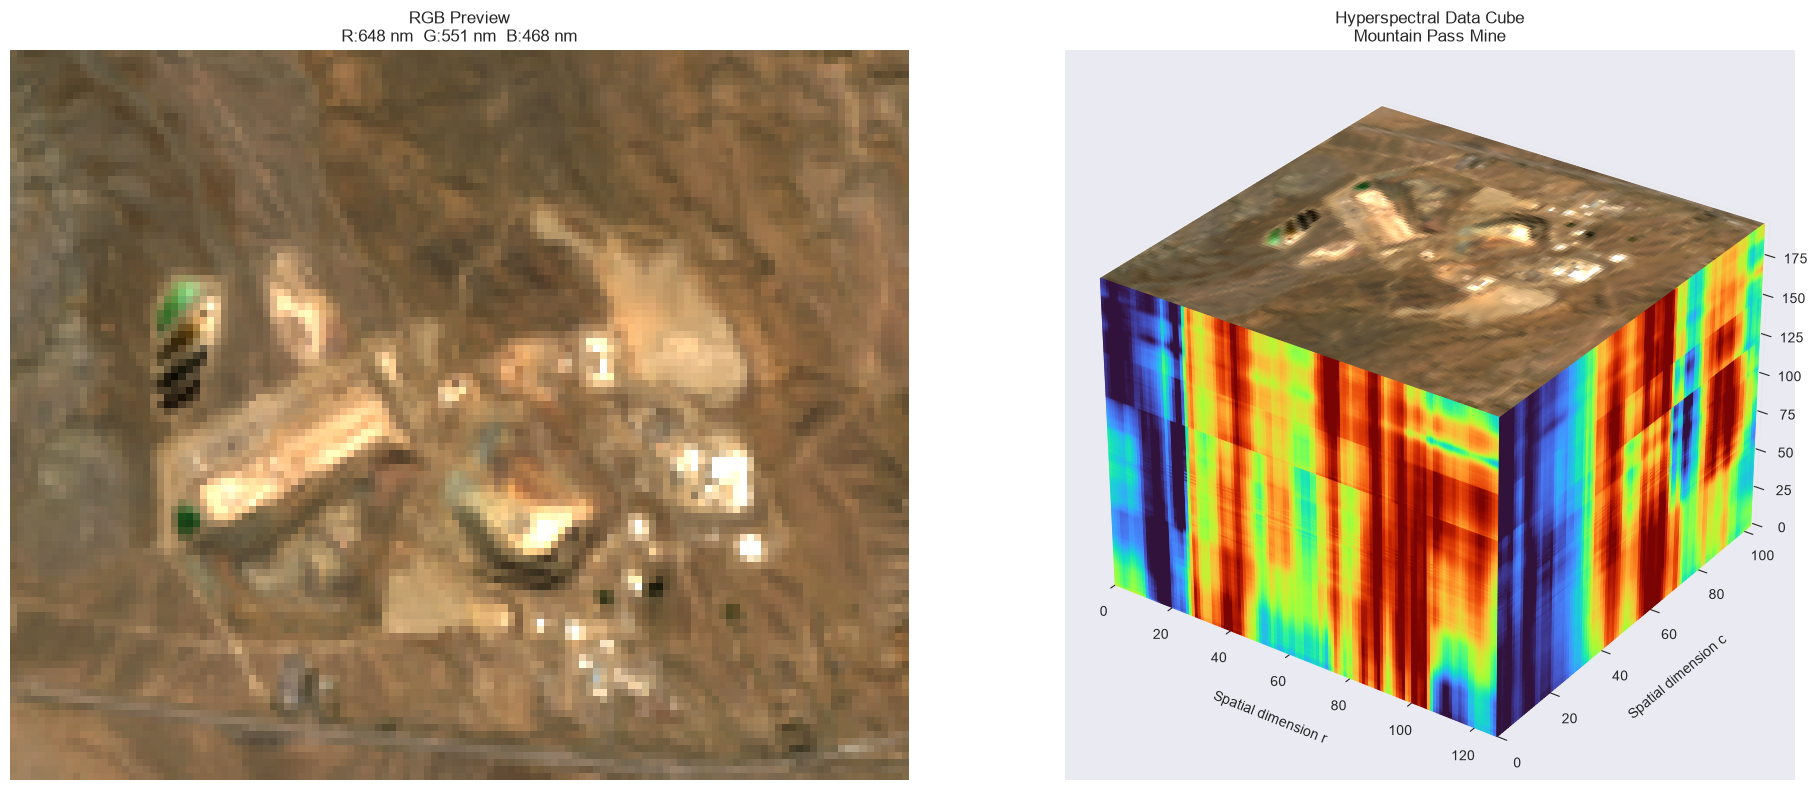

In [7]:
# ══════════════════════════════════════════════════════════════════
#  RGB PREVIEW + 3D CUBE VISUALIZATION
# ══════════════════════════════════════════════════════════════════
from src.ree_pca_viz import plot_rgb_and_cube
plot_rgb_and_cube(cube_data, wl_all)

## Helper Functions

In [8]:
# ══════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS for PCA
# ══════════════════════════════════════════════════════════════════

def flatten_cube(cube, min_valid=-20):
    """Flatten cube to 2D, removing invalid pixels."""
    nr, nc, nb = cube.shape
    X = cube.reshape(-1, nb)
    mask = ~np.any(np.isnan(X) | np.isinf(X), axis=1)#filter out possible outliers
    mask &= np.all(X > min_valid, axis=1)
    print(f'  Valid pixels: {mask.sum():,} / {len(mask):,} ({100*mask.sum()/len(mask):.1f}%)')
    return X[mask], mask, len(mask)

def scores_to_image(scores, mask, total, nr, nc):
    """Reconstruct 3D image from flattened scores."""
    n_comp = scores.shape[1]
    img = np.full((total, n_comp), np.nan)
    img[mask] = scores
    return img.reshape(nr, nc, n_comp)

def calculate_spectral_variability(eigenvalues):
    """Calculate spectral variability metrics."""
    total_var = eigenvalues.sum()
    explained_var_ratio = eigenvalues / total_var
    cumulative_var = np.cumsum(explained_var_ratio)
    return explained_var_ratio, cumulative_var

## 1. Principal Component Analysis (PCA)

### Mathematical Formulation

**Objective:** Maximize variance through orthogonal projection.

Given centered data matrix **X̃** = **X** - **m** ∈ ℝ^(n×b) where n = r×c pixels:

**Covariance Matrix:**
```
Σ = (1/n)X̃ᵀX̃
```

**Eigendecomposition:**
```
Σ = WΛWᵀ
```

where:
- **W** ∈ ℝ^(b×k) = eigenvectors (principal components/loadings)
- **Λ** = diag(λ₁, λ₂, ..., λₖ) with λ₁ ≥ λ₂ ≥ ... ≥ λₖ (eigenvalues)

**Projection (Scores):**
```
S = X̃W
```
where **S** ∈ ℝ^(n×k) = scores (spatial abundance maps)

**Variance Explained by Component i:**
```
ηᵢ = λᵢ / Σⱼλⱼ
```

### Computational Complexity

- Covariance computation: **O(nb²)**
- Eigendecomposition: **O(b³)**
- **Total: O(nb² + b³)**
- Space complexity: **O(b² + bk)**

For typical EnMAP data (n≈10⁴-10⁶, b≈200, k≈20): **~seconds**

### Interpretation

- Components ordered by **variance explained**
- PC1 captures maximum variance direction in spectral space
- Orthogonal components ensure no redundancy
- Works well for Gaussian-distributed features
- **Limitation:** May not capture non-Gaussian absorption dips optimally

In [9]:
# ══════════════════════════════════════════════════════════════════
#  PCA TRANSFORM (Variance-based)
# ══════════════════════════════════════════════════════════════════

print('PCA DECOMPOSITION (RAW DATA)\n')


X_pca, mask_pca, total_pca = flatten_cube(cube_data)
mean_pca = X_pca.mean(axis=0)
X_centered = X_pca - mean_pca

# Fit PCA
pca_model = PCA(n_components=N_COMP)
pca_scores = pca_model.fit_transform(X_centered)
pca_loadings = pca_model.components_.T  # (n_bands, n_comp)
pca_eigenvalues = pca_model.explained_variance_

# Reconstruct image
pca_img = scores_to_image(pca_scores, mask_pca, total_pca, n_rows, n_cols)

# Calculate variability
pca_var_ratio, pca_cumvar = calculate_spectral_variability(pca_eigenvalues)

print(f'\n PCA Complete')
print(f'Components: {N_COMP}')
print(f'Explained variance (top 5): {pca_var_ratio[:20]}')
print(f'Cumulative variance (top 5): {pca_cumvar[4]:.2%}')
print(f'Total variance captured: {pca_cumvar[-1]:.2%}')

PCA DECOMPOSITION (RAW DATA)

  Valid pixels: 13,312 / 13,312 (100.0%)

 PCA Complete
Components: 20
Explained variance (top 5): [8.92511834e-01 5.84915248e-02 3.34884786e-02 8.61744641e-03
 3.54477038e-03 9.25162411e-04 5.10406242e-04 4.80365971e-04
 4.16255350e-04 2.38117669e-04 1.81144873e-04 1.14935591e-04
 9.71141351e-05 9.42640980e-05 6.59219782e-05 5.87546051e-05
 5.49992696e-05 4.40015209e-05 3.34497429e-05 3.10518918e-05]
Cumulative variance (top 5): 99.67%
Total variance captured: 100.00%


## Spectral Variability: Scree Plots

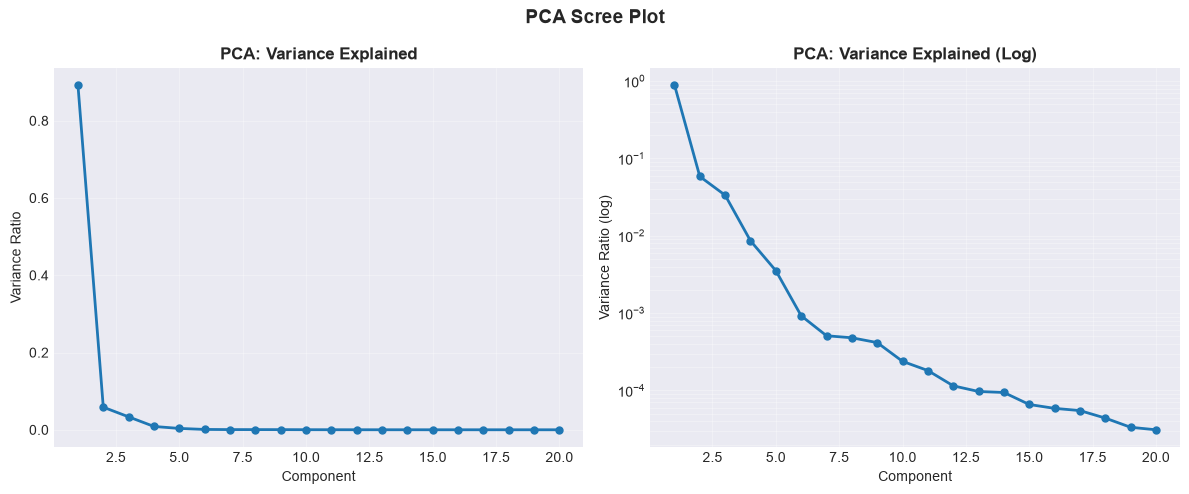

In [10]:
# ════════════════════════════════════════════════════════════════
#  SCREE PLOT: PCA (Linear vs Log Scale)
# ════════════════════════════════════════════════════════════════

from src.ree_pca_viz import plot_scree
plot_scree(pca_var_ratio, method_name='PCA') 

## Spatial Component Maps and Corresponding Loadings

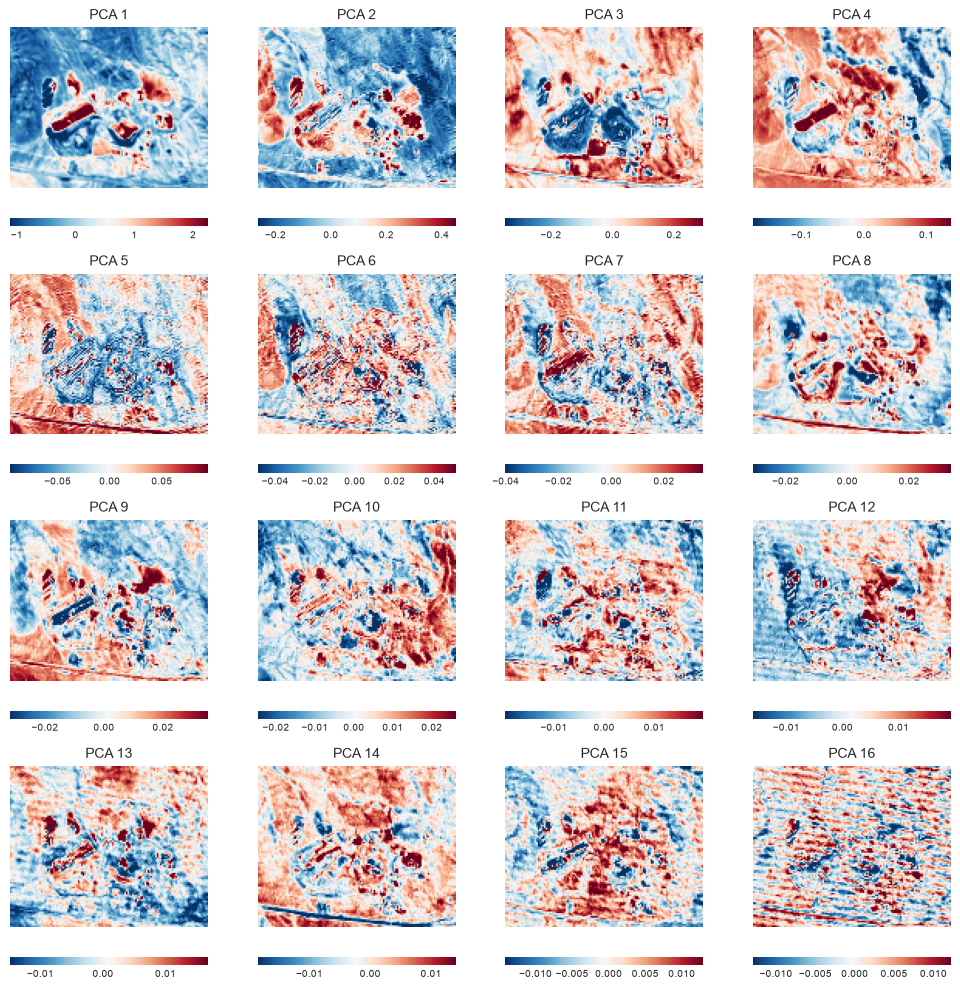

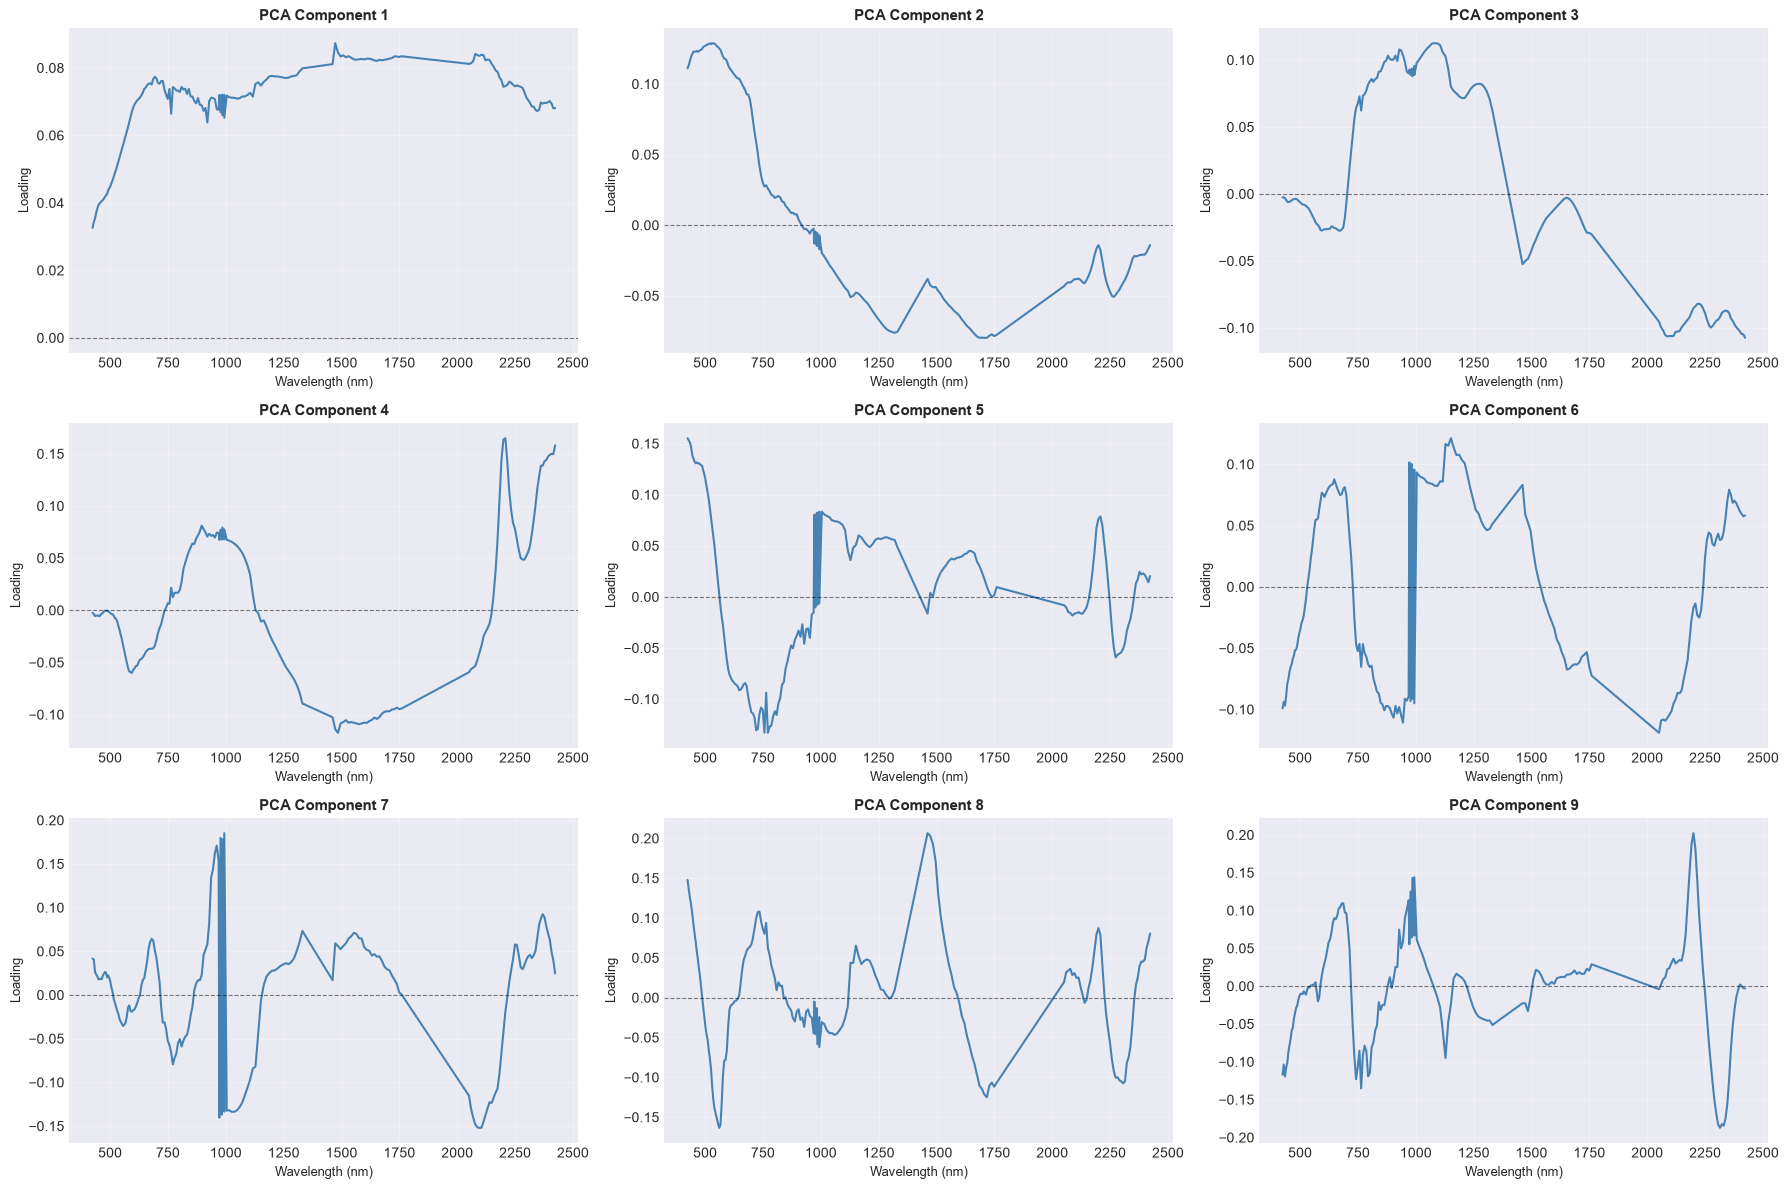

In [11]:
from src.ree_pca_viz import plot_spatial_components, plot_loadings

plot_spatial_components(pca_img, 'PCA')
plot_loadings(pca_loadings, wl_all, 'PCA', n_show=9)